# Evaluating Causal Inference Methods - Estimating Job Training Effects on Earnings

Can the methods of causal inference recover the causal effect identified via a randomised control trial? This notebook explores whether this is the case by replicating and extending the LaLonde (1986) paper. This paper explored whether econometric methods could recover effect of job training on future earnings discovered in a randomised controlled trial. Such exercises, where the true causal effect is known, are very useful for the practicioners of causal inference as they allow us to test our methods on real data. Much of the evaluation of causal inference methods is ran on synthetic datasets with a knows causal DAG.

Before any analysis it will be beneficial to state some notation and terminology here, and to show the central problem causal inference tries to solve. In this case study we want to know if job training has an effect on future earnings. Job training is the treatment and future earnings the response. We denote each individual as $Y_{i}$, furthermore, the future earnings of the $i^{ith}$ under the treatment is denoted as $Y_{i}^{1}$ and without the treatment $Y_{i}^{0}$. However, the core problem of causal inference is for each individual we only ever observe one of the two outcomes, they either had the treatment or they didn't. Therefore, we never observe all the data in the above equations and this means we must try to estimate. The potential outcomes are related to the observed outcomes via the treatment identifier $W_{i}$. That is,

$$
Y_{i} = W_{i}Y_{i}^{1} + (1 - W_{i})Y_{i}^{0}
$$

Notice $Y_{i}$ does not have superscript, this means it was observed. Furthermore, notice how the observed outcome is related to the potential outcomes. $W_{i}$ takes on a value of $1$ when the individual was assigned to the treatment and then the observed outcome is equal to $Y_{i}^{1}$ whereas when the individual is not assigned to the treatment and $W_{i}$ is $0$ then the observed outcome is $Y_{i}^{0}$.

In this case in particular we are interested in whether the earnings of the individuals who received the training increased. In the language of causal inference this means we want to estimate the **ATT** (average treatment effect of the treated). Thats abit of a mouthful but it simply means by how much did earnings increase for those people who received training vs the reality where they didn't take the training. Mathematicall we write,

$$
ATT = E[Y_{i}^{1} | W_{i} = 1] - E[Y_{i}^{0} | W_{i} = 1]
$$

However, notice that the second term on the right hand side of the equation is a potential outcome (or a counterfactual), it is the expected earnings of the people who took training in the reality where they didn't. As we do not observe this value (and never can) we must estimate it.

## Structure

This notebook uses the treated population from the Dehejia & Wahba (1999) study and as an observational control group uses the CIPS-1 group.

First the notebook calculates the experimental findings of the impact of the job training. The reason why this is an unbiased estimate of the true causal effect is explained. However, randomised controlled experiments are not always possible and this is why we have causal inference. Given this, the exploratory data analysis is presented, this highlights the selection bias problem between the two groups. The difference in the means between the two groups is presented as an estimate for the effectiveness of the job training and it is shown mathematically how the selection bias creeps in to make this estimate biased.

After this we test several causal inference methods to see how well they recover the causal effect of training. These are linear regression, propensity score matching and doubly robust estimators. Both propensity score matching and doubly robust estimators return a reasonable estimate of the causal effect. However, more work would need to be done to interrogate these estimates.

## Load Data

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import NearestNeighbors

In [2]:
base = "https://users.nber.org/~rdehejia/data/"
cols = ['treat','age','educ','black','hispan','married',
        'nodegree','re74','re75','re78']

treated = pd.read_csv(base + "nswre74_treated.txt",
                      sep=r'\s+', names=cols, header=None)

exp_control = pd.read_csv(base + "nswre74_control.txt",
                           sep=r'\s+', names=cols, header=None)

cps     = pd.read_csv(base + "cps_controls.txt",
                      sep=r'\s+', names=cols, header=None)
 
df = pd.concat([treated, cps], ignore_index=True)
df.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1.0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.0460
1,1.0,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.8940
2,1.0,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.4500
3,1.0,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,7506.1460
4,1.0,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,289.7899


In [3]:
df['treat'].value_counts()

treat
0.0    15992
1.0      185
Name: count, dtype: int64

## Experimental Findings

First lets display the effect found in the experimental setting. Assuming the experiment was properly designed and executed, this effect can be considered an unbiased estimator of the true causal effect because when we have a randomised control trial then it is the case that:

$$
(Y^{0},Y^{1}) \perp W
$$

The potential outcomes are independent of treatment. Using the rules of probability this means

$$
E[Y_{i}^{0} | W_{i} = 1] = E[Y_{i}^{0} | W_{i} = 0] = E[Y_{i}^{0}]
$$

That is the simple difference in means estimate is an unbiased estimate of the ATT. For more info on this see (Molak 2025: pg.89-93)

In [4]:
print((treated['re78'].mean() - exp_control['re78'].mean()).__round__(2))

1794.34


# EDA

The control group is on average older, better educated, more likely to be married, more likely to be hispanic and less likely to be black. This means it is almost certainly the case that

$$
E[Y_{i}^{0} | W_{i} = 0] \ne E[Y_{i}^{0} | W_{i} = 1]
$$

That is the expected value of the earnings of the control group when they don't receive the treatment (an observed value) is not equal to the expected value of the treated group had they not received the treatment (a potential outcome). In short this means we have selection bias

In [5]:
treated = df[df['treat'] == 1]
control = df[df['treat'] == 0]

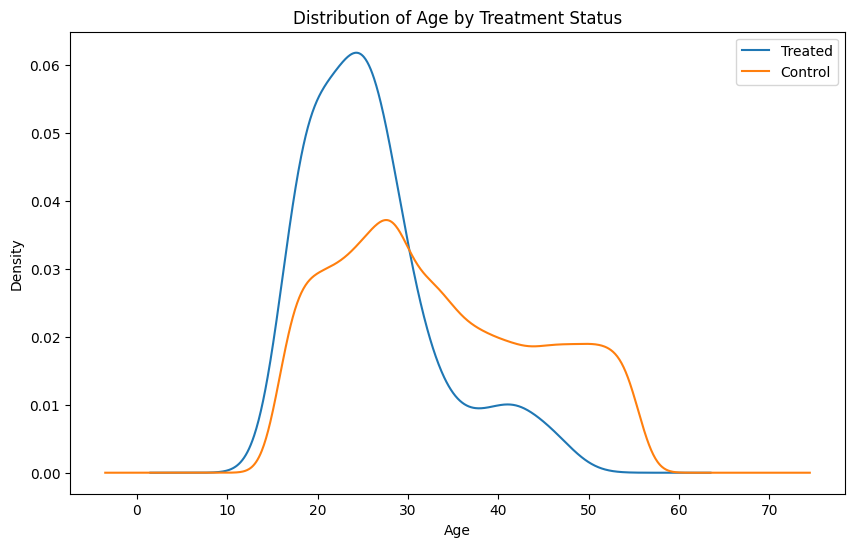

In [6]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

treated.age.plot.density(ax=ax, label='Treated')
control.age.plot.density(ax=ax, label='Control')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Distribution of Age by Treatment Status')
ax.legend()

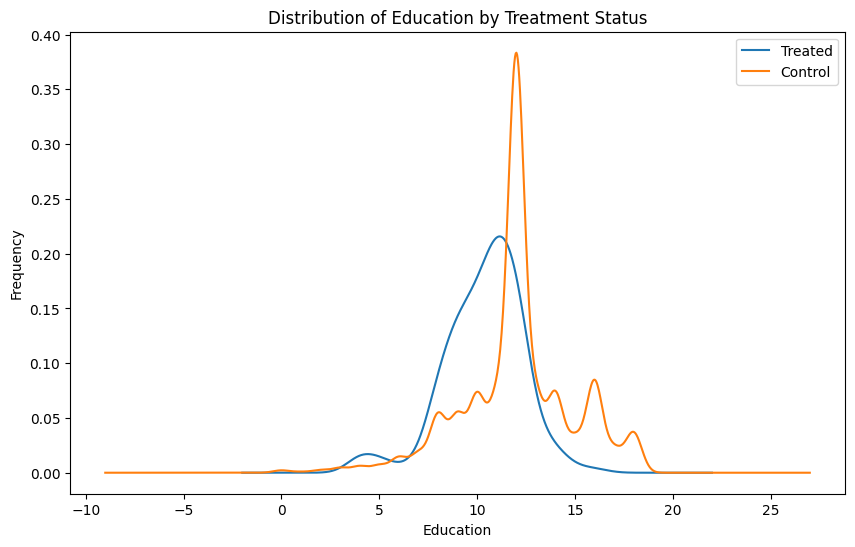

In [7]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

treated['educ'].plot.density(ax=ax, label='Treated')
control['educ'].plot.density(ax=ax, label='Control')
ax.set_xlabel('Education')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Education by Treatment Status')
ax.legend()

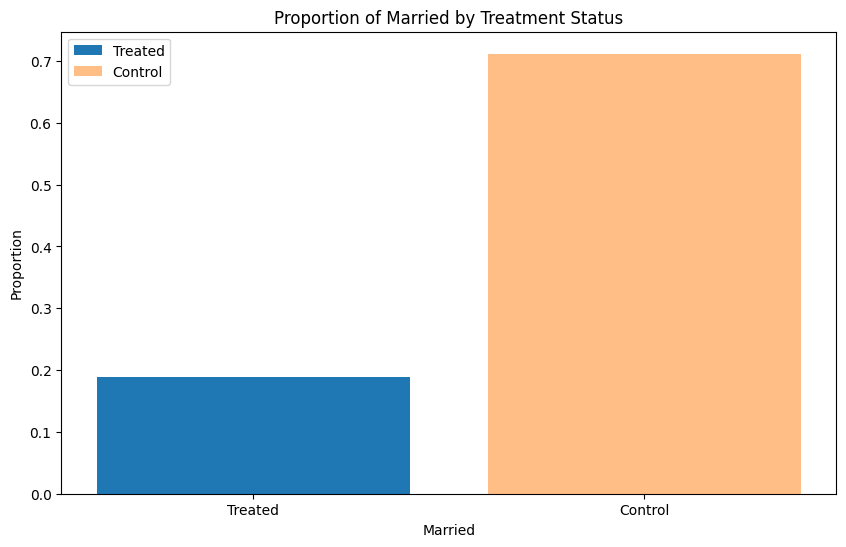

In [8]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['married'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['married'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Married')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Married by Treatment Status')
ax.legend()

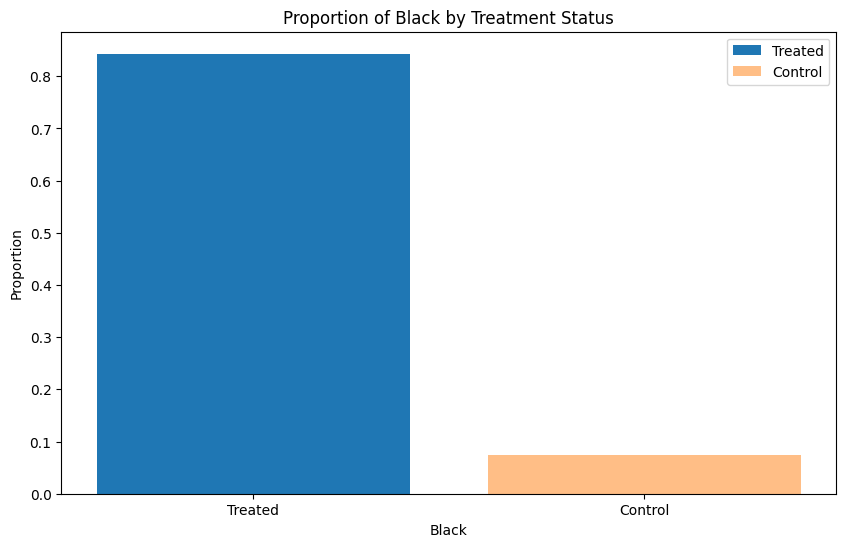

In [9]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['black'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['black'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Black')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Black by Treatment Status')
ax.legend()

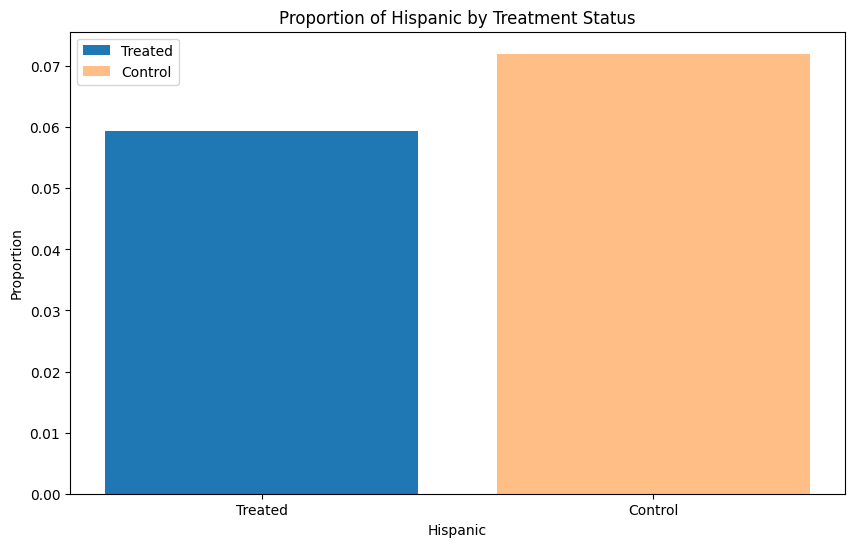

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['hispan'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['hispan'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Hispanic')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Hispanic by Treatment Status')
ax.legend()

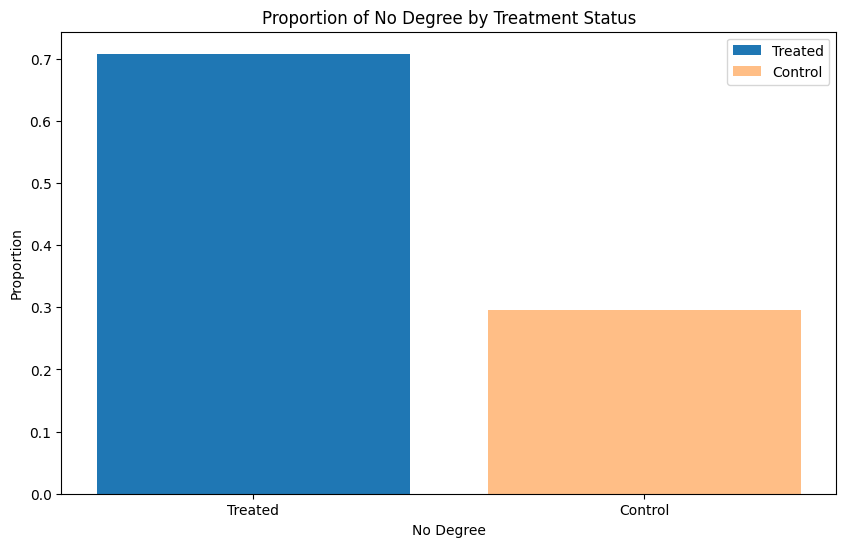

In [11]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['nodegree'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['nodegree'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('No Degree')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of No Degree by Treatment Status')
ax.legend()

## Naive Mean Difference Estimate

Below is the difference in means between the treated and control groups. The value is negative — does this mean job training had a negative effect on earnings? Of course not. There is selection bias, which makes this estimate biased for the ATT. To see this, start with the naive estimator and use the treatment assignment equation $Y_i = W_i Y_i^1 + (1-W_i)Y_i^0$ to rewrite each observed mean as a potential-outcome mean:

$$
E[Y_i \mid W_i = 1] - E[Y_i \mid W_i = 0] = E[Y_i^1 \mid W_i = 1] - E[Y_i^0 \mid W_i = 0]
$$

Now add and subtract the counterfactual $E[Y_i^0 \mid W_i = 1]$:

$$
= E[Y_i^1 \mid W_i = 1] - E[Y_i^0 \mid W_i = 1] + E[Y_i^0 \mid W_i = 1] - E[Y_i^0 \mid W_i = 0]
$$

The first two terms are the ATT; the last two are the selection bias — the difference in untreated potential outcomes between the two groups. If the groups would have had different average outcomes in the absence of treatment, the naive estimator is biased. Under random assignment the two groups are exchangeable, the selection bias term vanishes, and the difference in means is unbiased for the ATT.

In [12]:
print(treated['re78'].mean() - control['re78'].mean())

-8497.516142636992


## OLS Estimates

Firstly, linear regression is used to estimate the causal effect of job training on earnings. The value to estimate is $E[Y_{i}^{0} | W_{i} = 1]$. To do this with linear regression, take the control group and regress the response on the covariates. Now use this fitted model to predict the earnings of the treated group. The predicted value is an estimate for the earnings of the treated had they not been treated. However, the estimate of the ATT is quite poor at $689$, recall the experimental benchmark is $1794$.  

Why is the estimate so far off? Well there could be several reasons. Our model for earnings might not be correctly specified, at the moment the assumption is earnings is a linear function of the covariates, it is very likely that at least some of the covariates have a nonlinear relationship with the response or relate to the response through an interaction with other covariates. Also, the model could be missing some key predictors of earnings. Finally, the control group is very different from the treatment it could be that there are not many examples of people similar to the treatment in the control group and therefore the model cannot make good predictions for people in the treatment (the next method covered is designed to handle this).



In [22]:
model = sm.OLS(df[df['treat'] == 0]['re78'], sm.add_constant(df[df['treat'] == 0].drop(columns=['treat', 're78']))).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     1810.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        14:34:02   Log-Likelihood:            -1.6425e+05
No. Observations:               15992   AIC:                         3.285e+05
Df Residuals:                   15983   BIC:                         3.286e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5768.5879    446.056     12.932      0.0

In [24]:
counterfactual_earnings = model.predict(sm.add_constant(df[df['treat'] == 1].drop(columns=['treat', 're78'])))
print((df[df['treat'] == 1]['re78'] - counterfactual_earnings).mean())

689.8581362897039


## Propensity Score Matching

One causal inference method that has been proposed in the literature to recover the causal effect from the Lanlonde data is propensity score matching. Propensity score matching was introduced by Rubin & Rosenbaum (1983). A propensity score is the conditional probability of being assigned to the treatment given the covariates, written as $P(W_{i} = 1 | X_{i})$. Dehejia & Wahba (1999) applied propensity score matching to the Lalonde dataset and found it was better able to recover the causal effect than was OLS. In their paper they report an estimate of $1,582$ (Dehejia & Wahba 1999: p.1059) - pretty close to the true value of $1,794$.

The core idea in using propensity scores is they can be used to make the potential outcomes independent of the treatment. As stated above our problem is the control group cannot be used to estimate the outcome of treated group had they not been treated. However, Rubin & Rosenbaum (1983) state that if the potential outcomes, $(Y^{0}, Y^{1})$, are conditionally independent of the treatment $W$ given a set of covariates $X_{i}$ then the same conditional independence holds given the probability of $W=1 | X_{i}$.

$$
E[Y_{i}^{0} | W_{i} = 1] \ne E[Y_{i}^{0} | W_{i} = 0]
$$

$$
Y^{0}, Y^{1} \perp W | X \implies Y^{0}, Y^{1} \perp W | P(W_{i} = 1 | X_{i})
$$

$$
E[Y_{i}^{0} | W_{i} = 0, X_{i}] = E[Y_{i}^{0} | X_{i}]
$$

This means we need to estimate $P(W_{i} = 1 | X_{i})$ for each observation and perform nearest neighbours matching between each treatment unit and the closest $k$ non-treatment units for an estimate of the treatment effect. Why not just match directly on the covariates? There are a couple of reasons. Firstly, matching on many covariates suffers from the curse of dimensionality. Second, it is very unlikely that we have an exact match for each treated unit, especially because some of our covariates are real numbered. 

However, propensity score matching is not the saving grace of causal inference. Some researchers have pointed out paradoxes with the method and advise agaisnt using it (Molak 2023). However, a detailed analysis of the validity of propensity score matching is beyond the scope of this notebook.

### 1. Estimate propensity scores

In [15]:
lr = LogisticRegression()
lr.fit(df.drop(columns=['treat', 're78']), df['treat'])
propensity_scores = lr.predict_proba(df.drop(columns=['treat', 're78']))[:, 1]
log_odds_ratio = np.log(propensity_scores / (1 - propensity_scores))

c:\Users\caine\Documents\causal-inference\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


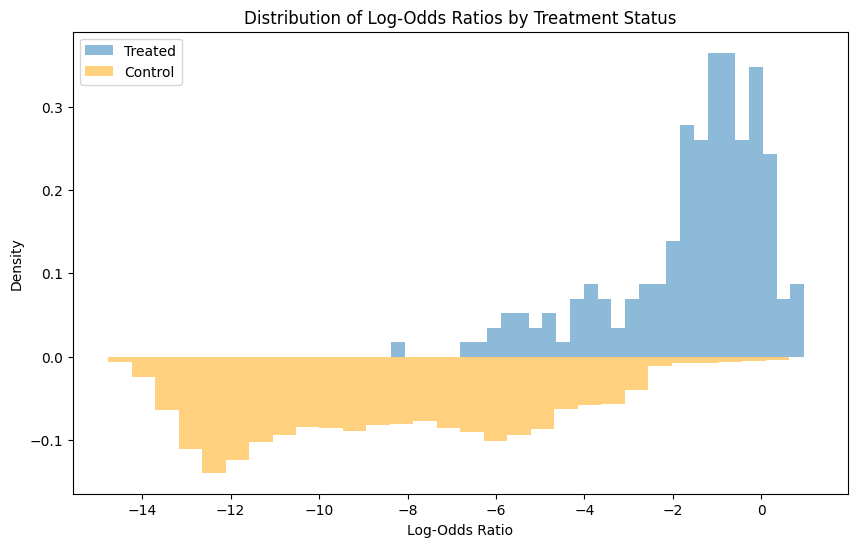

In [16]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(log_odds_ratio[df['treat'] == 1], alpha=0.5, bins=30, label='Treated', density=True)
control_density, control_bins = np.histogram(log_odds_ratio[df['treat'] == 0], bins=30, density=True)
ax.bar(control_bins[:-1], control_density*-1, alpha=0.5, label='Control', width=np.diff(control_bins), align='edge', color='orange')
ax.set_xlabel('Log-Odds Ratio')
ax.set_ylabel('Density')
ax.set_title('Distribution of Log-Odds Ratios by Treatment Status')
ax.legend()

### 2. Matching

The estimated propensity scores are now used for matching. A nearest neighbours model is fit on the control group, then for each treated unit the closest control unit by propensity score is selected as the match. All selected control units are taken to be an unibiased estimate for $E[Y_{i}^{0} | W_{i} = 1]$, therefore the means of the 1978 income for the treatment and the matched control group are compared as an estimate for ATT. Also notice how the love plot displays that after matching the distribution of the propensity scores between the control and the treated are very similar.

This results in an estimate of the causal effect of $1,440$ much better than the OLS estimate. This is different to the Dehejia & Wahba estimate, the authors grouped observations into strata based on the propensity score and then checked if the covariates within the strata were independent of the treatment. This means their propensity score model is a little different to ours and therefore different estimates based on matching

In [17]:
treat_mask: np.ndarray = df['treat'].values == 1
treat_pos = np.where(treat_mask)[0]
control_pos = np.where(~treat_mask)[0]

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(propensity_scores[control_pos].reshape(-1, 1))
distances, indices = nn.kneighbors(propensity_scores[treat_pos].reshape(-1, 1))

# Map kneighbors' relative indices back to original positions
matched_control_pos = control_pos[indices.flatten()]

treat_log_odds = log_odds_ratio[treat_pos]
control_log_odds = log_odds_ratio[matched_control_pos]

In [18]:
len(np.unique(matched_control_pos))

142

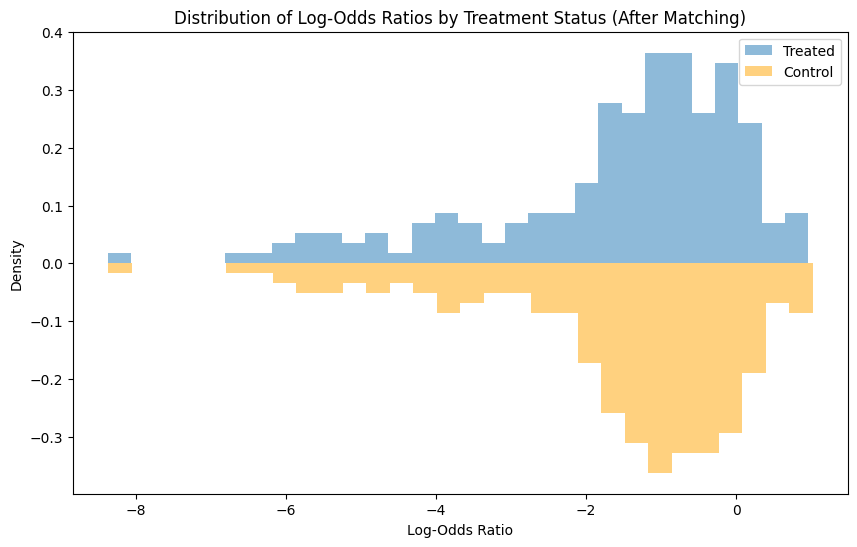

In [19]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(treat_log_odds, alpha=0.5, bins=30, label='Treated', density=True)
control_density, control_bins = np.histogram(control_log_odds, bins=30, density=True)
ax.bar(control_bins[:-1], control_density*-1, alpha=0.5, label='Control', width=np.diff(control_bins), align='edge', color='orange')
ax.set_xlabel('Log-Odds Ratio')
ax.set_ylabel('Density')
ax.set_title('Distribution of Log-Odds Ratios by Treatment Status (After Matching)')
ax.legend()

In [20]:
estimate = df['re78'].values[treat_pos].mean() - df['re78'].values[matched_control_pos].mean()
print(round(estimate, 2))

1439.82


## Doubly Robust Estimator

Finally, a doubly robust estimator is used to estimate the causal effect of job training. A doubly robust estimator combines an outcome model and a treatment model into a single estimator. The outcome model predicts the outcome from the covariates (for example, the linear regression above); the treatment model predicts treatment from the covariates (for example, the propensity score model). The two are combined as follows:

$$
ATT = \frac{1}{N_t}\sum_{i=1}^{N}\left[ W_i Y_i \;-\; \frac{Y_i(1-W_i)\hat{e}_i + \hat{u}_0(X_i)(W_i - \hat{e}_i)}{1 - \hat{e}_i} \right]
$$

The first term inside the brackets is the mean outcome among the treated. The second term estimates the counterfactual $E[Y_i^0 \mid W_i = 1]$ — what the treated units would have averaged if untreated.

To unpack the terms: $W_i$ is the treatment indicator, $\hat{e}_i$ is the estimated propensity score, and $\hat{u}_0(X_i)$ is the outcome regression fit on the controls.

The fraction does different work depending on $W_i$:

- **For a treated unit** ($W_i = 1$): the fraction simplifies to $\hat{u}_0(X_i)$ — the regression's prediction of what this treated person's outcome would have been if untreated.
- **For a control unit** ($W_i = 0$): the fraction simplifies to $\frac{\hat{e}_i}{1 - \hat{e}_i}(Y_i - \hat{u}_0(X_i))$ — the control's residual, weighted by the odds that this unit would have been treated. Controls who look like treated units (high $\hat{e}_i$) get large weights; controls who look nothing like the treated get downweighted.

The beauty of doubly robust estimators is that if at least one of the treatment or outcome models is correctly specified, the estimator is consistent (unbiased in the limit). It essentially gives you two shots at getting a correct estimate.

In [25]:
# Estimate propensity scores
log_reg = LogisticRegression()
log_reg.fit(df.drop(columns=['treat', 're78']), df['treat'])
propensity_scores = log_reg.predict_proba(df.drop(columns=['treat', 're78']))[:, 1]

# Fit outcome regression model on control group
lin_reg = LinearRegression()
lin_reg.fit(df[df['treat'] == 0].drop(columns=['treat', 're78']), df[df['treat'] == 0]['re78'])

# Outcome model for control group
predicted_control_values = lin_reg.predict(df.drop(columns=['treat', 're78']))


c:\Users\caine\Documents\causal-inference\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
W = df['treat'].values
Y = df['re78'].values
e = propensity_scores
u0 = predicted_control_values

nt = W.sum()

numerator = Y * (1 - W) * e + u0 * (W - e)
fraction = numerator / (1 - e)

doubly_robust_estimate = (1 / nt) * np.sum(W * Y - fraction)
print(round(doubly_robust_estimate, 2))

1628.92


## References

Dehejia, R. H., & Wahba, S. (1999). Causal effects in nonexperimental
studies: Reevaluating the evaluation of training programs. *Journal of
the American Statistical Association*, 94(448), 1053–1062.

Facure, M. (2022). *Causal inference for the brave and true*. Online
book. https://matheusfacure.github.io/python-causality-handbook/

King, G., & Nielsen, R. (2019). Why propensity scores should not be
used for matching. *Political Analysis*, 27(4), 435–454.

LaLonde, R. J. (1986). Evaluating the econometric evaluations of
training programs with experimental data. *American Economic Review*,
76(4), 604–620.

Molak, A. (2023). *Causal inference and discovery in Python: Unlock the
secrets of modern causal machine learning with DoWhy, EconML, PyTorch
and more*. Packt Publishing.

Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the
propensity score in observational studies for causal effects.
*Biometrika*, 70(1), 41–55.